### Project Proposals (individual work)

Your project proposal should reflect your own individual work and should not overlap too much with the work of your peers. Project proposals should take the form of a JupyterLab notebook that includes the following sections:

* Introduction and Background for the problem you are interested in.
    - What is the question you hope you can answer?
    - Why is the question important to you?
    - What are you hoping to achieve with the project?
* Description of the data.
    - Where did you get your data?
    - What data is found in your data set?
    - Are there any ethical concerns with using the data or how the data was obtained?
    - Is there a public location where the data is freely available? If so where? If not why?
* Initial Exploratory Data Analysis
    - Definition of all variables (or explanation for why you are not considering some variables)
    - Descriptive statistics for the data set, counts of the variables, value counts (frequency tables) for each categorical variable of interest.
    - Plots that help a reader understand your data.
    - Initial analysis to answer initial data questions.
* Proposal for further study.
    - What larger questions would you like to try to answer?
    - What predictive analysis do you think might be possible?
    - Are there any larger impacts that your study might have?

Proposals should be submitted as .ipynb files on Canvas. Make sure your notebook can be run completely. If it requires a data file make sure to submit that file too. It should contain just as many words and as much description of the problem/results as it does code.

The Question:
What was the META (Most Effective Tactic Available) during the 2025 VCT (Valorant Champions Tour) Season?

This question is important to me because I have followed and watched the VCT season and the data regarding which agents and combination of agents worked best will be applicable to defining which agents will be the strongest in the future.

I'm hoping to determine which agents were the strongest for each map and figure out what criteria made them the strongest.

The data is being scraped from vlr.gg, a valorant stats website for tracking professional Valorant games.

The data contains information about each professional Valorant match, how each person within each match did, and what agents they were playing to make it happen.

I do not believe there are any ethical concerns to using the data.

The data is taken from a publically available source designed to display statistical information of Valorant matches to users. It can be found at vlr.gg, and it is scraping everything from the VCT 2025 Circuit.

I have not fully scraped all the data yet. There are 65 variables in the data set, and far too many to name individually, especially given the triviality of most of them. That being said, it tracks information about the physical player (team, player ign), game-specific information (map, agent), and the statistics for the game, divided up into 3 categories: attack statistics, defense statistics, and overall statistics. It also contains generic information about the game result.

In [1]:
import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import plotly.express as px
from plotly.subplots import make_subplots
import plotly.io as pio
pio.renderers.defaule = 'colab'

from itables import show

In [34]:
DF = pd.read_csv(r'C:\Users\garrr\Data Science 101\silksong\FinalProjectProposal\americas_stage2_export.csv')
DF

,Map,Player,Team,Agent,Overall VLR Rating,Overall ACS,Overall Kills,Overall Deaths,Overall Assists,Overall +/-,...,Total Defense Half Rounds,Overtime Attack Rounds Won,Overtime Attack Rounds Lost,Total Overtime Attack Rounds,Overtime Defense Rounds Won,Overtime Defense Rounds Lost,Total Overtime Defense Rounds,Overtime Rounds Won,Overtime Rounds Lost,Total Overtime Rounds
0,Haven,mitch,C9,skye,1.51,250,18,8,5,10,...,6,0,0,0,0,0,0,0,0,0
1,Haven,OXY,C9,jett,1.42,336,23,14,3,9,...,6,0,0,0,0,0,0,0,0,0
2,Haven,v1c,C9,omen,1.28,189,12,8,7,4,...,6,0,0,0,0,0,0,0,0,0
3,Haven,Xeppaa,C9,killjoy,1.20,221,13,10,5,3,...,6,0,0,0,0,0,0,0,0,0
4,Haven,neT,C9,viper,0.84,132,9,8,3,1,...,6,0,0,0,0,0,0,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1045,Ascent,brawk,NRG,sova,1.31,233,20,13,5,7,...,12,0,0,0,0,0,0,0,0,0
1046,Ascent,mada,NRG,jett,1.00,230,17,17,6,0,...,12,0,0,0,0,0,0,0,0,0
1047,Ascent,skuba,NRG,vyse,1.00,159,14,14,8,0,...,12,0,0,0,0,0,0,0,0,0
1048,Ascent,Ethan,NRG,kayo,0.93,181,12,16,13,-4,...,12,0,0,0,0,0,0,0,0,0


In [19]:
show(DF)

Loading ITables v2.5.2 from the internet... (need help?)


This is just a portion of the data, but it's what i've scraped so far. I'll make charts of the pickrates of agents on Haven and Corrode, two maps in Valorant, and we'll see how they compare

In [64]:
DF_haven = DF[DF['Map'] == 'Haven']
DF_haven

,Map,Player,Team,Agent,Overall VLR Rating,Overall ACS,Overall Kills,Overall Deaths,Overall Assists,Overall +/-,...,Total Defense Half Rounds,Overtime Attack Rounds Won,Overtime Attack Rounds Lost,Total Overtime Attack Rounds,Overtime Defense Rounds Won,Overtime Defense Rounds Lost,Total Overtime Defense Rounds,Overtime Rounds Won,Overtime Rounds Lost,Total Overtime Rounds
0,Haven,mitch,C9,skye,1.51,250,18,8,5,10,...,6,0,0,0,0,0,0,0,0,0
1,Haven,OXY,C9,jett,1.42,336,23,14,3,9,...,6,0,0,0,0,0,0,0,0,0
2,Haven,v1c,C9,omen,1.28,189,12,8,7,4,...,6,0,0,0,0,0,0,0,0,0
3,Haven,Xeppaa,C9,killjoy,1.20,221,13,10,5,3,...,6,0,0,0,0,0,0,0,0,0
4,Haven,neT,C9,viper,0.84,132,9,8,3,1,...,6,0,0,0,0,0,0,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
955,Haven,OXY,C9,neon,1.31,273,24,16,4,8,...,12,0,0,0,0,0,0,0,0,0
956,Haven,Xeppaa,C9,vyse,1.26,264,21,18,13,3,...,12,0,0,0,0,0,0,0,0,0
957,Haven,v1c,C9,omen,1.25,262,22,15,12,7,...,12,0,0,0,0,0,0,0,0,0
958,Haven,neT,C9,viper,1.07,199,18,15,3,3,...,12,0,0,0,0,0,0,0,0,0


In [65]:
DF_haven_agents = pd.DataFrame(DF_haven['Agent'].value_counts())
DF_haven_agents

,count
Agent,
omen,36
sova,27
cypher,20
yoru,19
neon,19
viper,16
killjoy,12
iso,7
jett,7


In [66]:
DF_haven_agents['Haven Pick Rate'] = DF_haven_agents['count']/36
# There are 18 Haven Games in the set, times 2 teams for a maximum of 36 times an agent could be picked. Pick Rate is Measuring How Often Each Agent Was Picked
DF_haven_agents

,count,Haven Pick Rate
Agent,,
omen,36,1.000000
sova,27,0.750000
cypher,20,0.555556
yoru,19,0.527778
neon,19,0.527778
viper,16,0.444444
killjoy,12,0.333333
iso,7,0.194444
jett,7,0.194444


In [51]:
DF_haven_agents.index

Index(['omen', 'sova', 'cypher', 'yoru', 'neon', 'viper', 'killjoy', 'iso',
       'jett', 'skye', 'vyse', 'breach', 'fade'],
      dtype='object', name='Agent')

In [76]:
DF_haven_agents['Agent'] = ['omen', 'sova', 'cypher', 'yoru', 'neon', 'viper', 'killjoy', 'iso',
       'jett', 'skye', 'vyse', 'breach', 'fade']
DF_haven_agents.index = [1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13]
DF_haven_agents

,count,Haven Pick Rate,Agent
1,36,1.000000,omen
2,27,0.750000,sova
3,20,0.555556,cypher
4,19,0.527778,yoru
5,19,0.527778,neon
6,16,0.444444,viper
7,12,0.333333,killjoy
8,7,0.194444,iso
9,7,0.194444,jett
10,6,0.166667,skye


In [68]:
DF_corrode = DF[DF['Map'] == 'Corrode']
DF_corrode_agents = pd.DataFrame(DF_corrode['Agent'].value_counts())
DF_corrode_agents['Corrode Pick Rate'] = DF_corrode_agents['count']/30
DF_corrode_agents.index

Index(['omen', 'viper', 'neon', 'fade', 'vyse', 'sova', 'chamber', 'waylay',
       'sage', 'yoru', 'kayo', 'raze', 'skye', 'astra'],
      dtype='object', name='Agent')

In [77]:
DF_corrode_agents['Agent'] = ['omen', 'viper', 'neon', 'fade', 'vyse', 'sova', 'chamber', 'waylay',
       'sage', 'yoru', 'kayo', 'raze', 'skye', 'astra']
DF_corrode_agents.index = [1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14]
DF_corrode_agents

,count,Corrode Pick Rate,Agent
1,29,0.966667,omen
2,27,0.900000,viper
3,18,0.600000,neon
4,18,0.600000,fade
5,13,0.433333,vyse
6,11,0.366667,sova
7,8,0.266667,chamber
8,6,0.200000,waylay
9,5,0.166667,sage
10,4,0.133333,yoru


In [82]:
DF_haven_corrode_agents = pd.merge(DF_haven_agents, DF_corrode_agents, on='Agent', how='outer')
DF_haven_corrode_agents

,count_x,Haven Pick Rate,Agent,count_y,Corrode Pick Rate
0,NaN,NaN,astra,1.0,0.033333
1,4.0,0.111111,breach,NaN,NaN
2,NaN,NaN,chamber,8.0,0.266667
3,20.0,0.555556,cypher,NaN,NaN
4,3.0,0.083333,fade,18.0,0.600000
5,7.0,0.194444,iso,NaN,NaN
6,7.0,0.194444,jett,NaN,NaN
7,NaN,NaN,kayo,4.0,0.133333
8,12.0,0.333333,killjoy,NaN,NaN
9,19.0,0.527778,neon,18.0,0.600000


In [96]:
DF_haven_corrode_agents = DF_haven_corrode_agents.fillna(0)
DF_haven_corrode_agents

,count_x,Haven Pick Rate,Agent,count_y,Corrode Pick Rate
0,0.0,0.000000,astra,1.0,0.033333
1,4.0,0.111111,breach,0.0,0.000000
2,0.0,0.000000,chamber,8.0,0.266667
3,20.0,0.555556,cypher,0.0,0.000000
4,3.0,0.083333,fade,18.0,0.600000
5,7.0,0.194444,iso,0.0,0.000000
6,7.0,0.194444,jett,0.0,0.000000
7,0.0,0.000000,kayo,4.0,0.133333
8,12.0,0.333333,killjoy,0.0,0.000000
9,19.0,0.527778,neon,18.0,0.600000


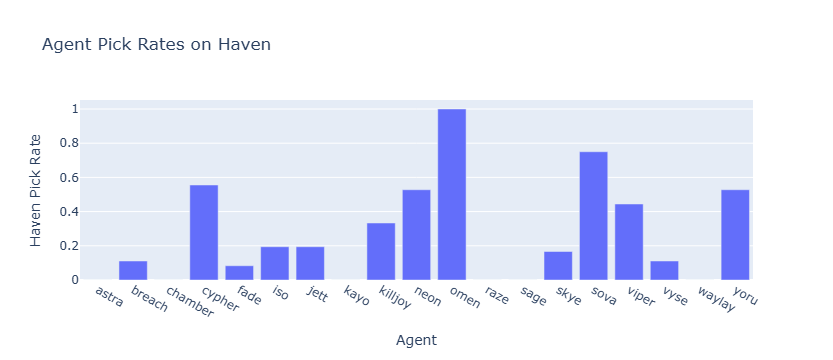

In [100]:
bar_haven_agents = px.bar(
    DF_haven_corrode_agents,
    x='Agent',
    y='Haven Pick Rate',
    title='Agent Pick Rates on Haven')
bar_corrode_agents = px.bar(
    DF_haven_corrode_agents,
    x='Agent',
    y='Corrode Pick Rate',
    title='Agent Pick Rates on Corrode')
scatter_haven_corrode_agents = px.scatter(
    DF_haven_corrode_agents,
    x='Haven Pick Rate',
    y='Corrode Pick Rate',
    width=600,
    height=600,
    title='Haven vs Corrode Agent Pick Rates',
    hover_data='Agent')
bar_haven_agents.show()

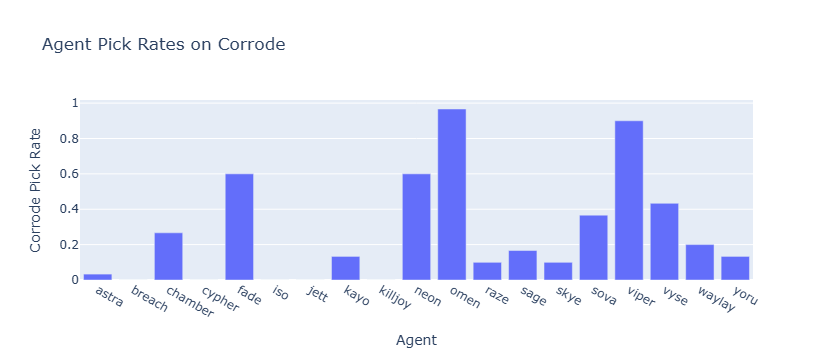

In [98]:
bar_corrode_agents.show()

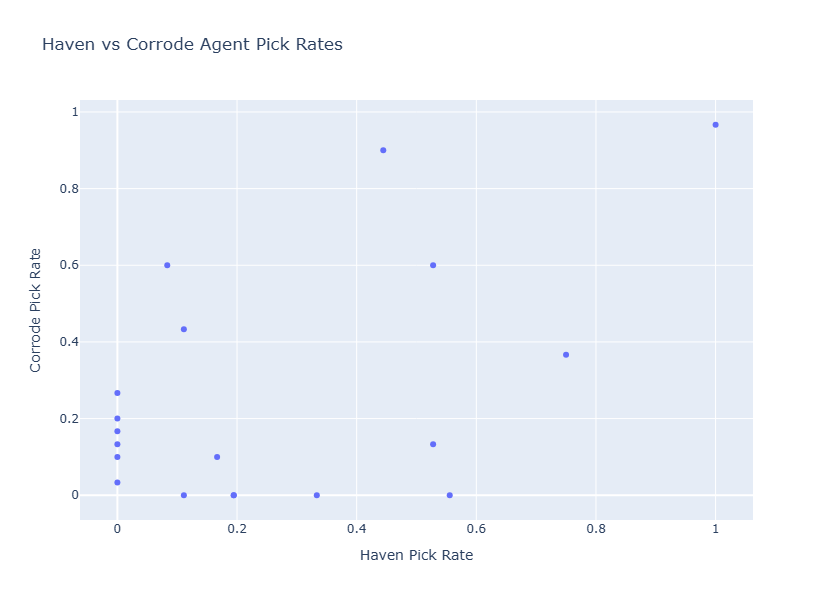

In [101]:
scatter_haven_corrode_agents.show()

Hopefully this has gone to show the difference in which agents are the most valuable to pick on different maps. Each map has it's own quirks, and the same agents on every map won't do the trick. This is why data analysis matters here— every map has it's own trends and this graph only shows the pick rate of professional players, who could be missing the data on what agents actually succeed and thrive on each map. I'd like to evaluate how the success of the agents vary versus each other and figure out what truly is the best team composition for every map in Valorant. While the data is unlikely to make a very big splash, it could assist coaches who are trying to work out what group of agents to play based on real world results.